In [2]:
import snntorch as snn
import torch

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "c:\Users\Emiel\Documents\Study\AI x CNS\Thesis\Thesis-Code\.venv\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [5]:
batch_size = 128
data_path = '/tmp/data/mnist'
num_classes = 10

dtype = torch.float

In [6]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))
])

mnist_train = datasets.MNIST(data_path, train=True, download=True, transform=transform)

100.0%
100.0%
100.0%
100.0%


In [8]:
from snntorch import utils

subset = 10
mnist_train = utils.data_subset(mnist_train, subset)
print(f"The size of mnist_train is {len(mnist_train)}")

The size of mnist_train is 600


In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    mnist_train, 
    batch_size=batch_size, 
    shuffle=True
)

In [40]:
num_steps = 100
raw_vector = torch.ones(num_steps)*0.5
rate_coded_vector = torch.bernoulli(raw_vector)

print(f"Converted vector: {rate_coded_vector}")
print(f"The output is spiking {rate_coded_vector.sum()*100/len(rate_coded_vector):.2f}% of the time.")

Converted vector: tensor([1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1.,
        0., 1., 0., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 1., 1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1.,
        0., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 1.,
        0., 1., 0., 0., 1., 0., 0., 0., 1., 1.])
The output is spiking 54.00% of the time.


In [42]:
from snntorch import spikegen

data = iter(train_loader)
data_it, targets_it = next(data)

spike_data = spikegen.rate(data_it, num_steps=num_steps)

print(spike_data.size())

torch.Size([100, 128, 1, 28, 28])


In [51]:
import matplotlib.pyplot as plt
import snntorch.spikeplot as splt
from IPython.display import HTML

In [48]:
spike_data_sample = spike_data[:, 0, 0]
print(spike_data_sample.size())

torch.Size([100, 28, 28])


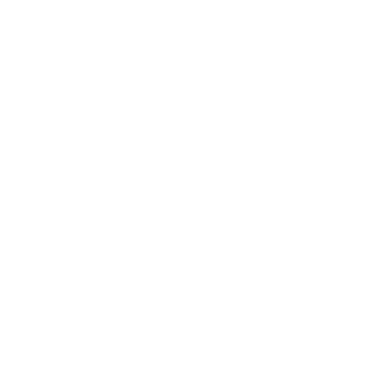

In [54]:
fig, ax = plt.subplots()
anim = splt.animator(spike_data_sample, fig, ax)

HTML(anim.to_html5_video())

In [55]:
print(f"The corresponding target is: {targets_it[0]}")

The corresponding target is: 8


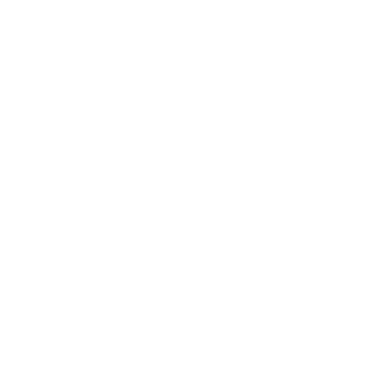

In [56]:
spike_data = spikegen.rate(
    data_it, 
    num_steps=num_steps, 
    gain=0.25,
)

spike_data_sample2 = spike_data[:, 0, 0]
fig, ax = plt.subplots()
anim = splt.animator(spike_data_sample2, fig, ax)
HTML(anim.to_html5_video())

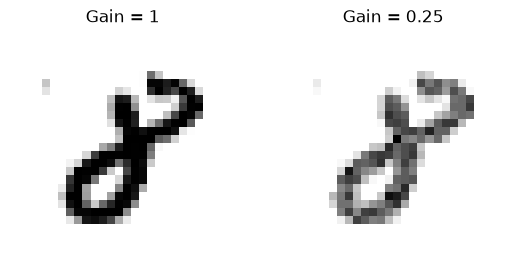

In [57]:
plt.figure(facecolor="w")
plt.subplot(1, 2, 1)
plt.imshow(spike_data_sample.mean(axis=0).reshape((28,-1)).cpu(), cmap='binary')
plt.axis('off')
plt.title('Gain = 1')

plt.subplot(1, 2, 2)
plt.imshow(spike_data_sample2.mean(axis=0).reshape((28,-1)).cpu(), cmap='binary')
plt.axis('off')
plt.title('Gain = 0.25')
plt.show()

In [ ]:
spike_data_sample2 = spike_data_sample2.reshape((num_steps, -1))

fig = plt.figure(facecolor="w", figsize=(10, 5))
ax = fig.add_subplot(111)
splt.raster(spike_data_sample2, ax, s=1.5, c="black")

plt.title("Input Layer")
plt.xlabel("Time Steps")
plt.ylabel("Neuron Number")
plt.show()